# Result Set Overlap Analysis

This notebook analyzes how similar or different the **final returned result nodes** are between native RAG and the two-call baseline.

Primary metric:

`result_jaccard_overlap = shared_result_count / (shared_result_count + native_only_count + baseline_only_count)`

Interpretation:

- `1.0` means both methods returned exactly the same final result node set.
- `0.0` means the two methods returned completely disjoint final result node sets.
- Lower Jaccard overlap means native RAG changed the final retrieval output more strongly.

This metric does **not** say which method is more correct. It tells us whether native seed reranking meaningfully changed the final set of graph results.

## Setup

If this notebook kernel does not already have the plotting packages installed, run:

```bash
pip install pandas matplotlib seaborn
```

Use the project kernel if possible:

`Neo4j RAG Benchmark (.venv)`

In [13]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

try:
    import seaborn as sns
    sns.set_theme(style="whitegrid", context="notebook")
except ImportError:
    sns = None
    plt.style.use("ggplot")

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

## Load Data

Update `CSV_PATH` when you want to analyze a newer comparison-quality run.

In [14]:
BENCHMARK_ROOT = Path("..").resolve()
CSV_PATH = BENCHMARK_ROOT / "results" / "eval" / "comparison_quality-20260416-004654.csv"

if not CSV_PATH.exists():
    raise FileNotFoundError(f"Could not find quality CSV: {CSV_PATH}")

raw_df = pd.read_csv(CSV_PATH)
print(f"Loaded {len(raw_df):,} rows from {CSV_PATH}")
raw_df.head()

Loaded 1,200 rows from /Users/chelseahuynh/CSCI543-Project-2-Neo4j/neo4j/neo4j-rag-benchmark/results/eval/comparison_quality-20260416-004654.csv


,query_id,top_k,depth,native_seed_count,baseline_seed_count,native_mean_seed_ann_score,baseline_mean_seed_ann_score,seed_ann_score_difference,native_mean_pairwise_neighborhood_overlap,baseline_mean_pairwise_neighborhood_overlap,neighborhood_overlap_difference,native_row_count,baseline_row_count,row_count_difference,row_count_ratio,result_jaccard_overlap,shared_result_count,native_only_count,baseline_only_count,native_unique_label_count,baseline_unique_label_count,native_label_entropy,baseline_label_entropy,native_majority_label_fraction,baseline_majority_label_fraction
0,paper-93434-topk-1-depth-0,1,0,1,1,1.0,0.999703,0.000297,NaN,NaN,NaN,1,1,0,1.000000,0.000000,0,1,1,1,1,0.000000,0.000000,1.000000,1.000000
1,paper-93434-topk-1-depth-1,1,1,1,1,1.0,0.999703,0.000297,NaN,NaN,NaN,10,31,-21,0.322581,0.000000,0,10,31,2,2,0.468996,0.205593,0.900000,0.967742
2,paper-93434-topk-1-depth-2,1,2,1,1,1.0,0.999703,0.000297,NaN,NaN,NaN,180,747,-567,0.240964,0.051020,45,135,702,7,14,0.877432,0.912614,0.811111,0.817938
3,paper-93434-topk-3-depth-0,3,0,3,3,1.0,0.984368,0.015632,0.0,0.009009,-0.009009,3,3,0,1.000000,0.000000,0,3,3,1,1,0.000000,0.000000,1.000000,1.000000
4,paper-93434-topk-3-depth-1,3,1,3,3,1.0,0.984368,0.015632,0.0,0.009009,-0.009009,29,44,-15,0.659091,0.042857,3,26,41,3,3,0.999700,0.312220,0.724138,0.954545


## Data Cleaning

We convert result-set columns to numeric values and compute a few additional fields:

- `union_result_count`: total unique nodes returned by either method
- `native_changed_results`: whether native and baseline returned different final node sets
- `absolute_row_count_difference`: absolute row count difference between methods

Important:

- `row_count_difference = native_row_count - baseline_row_count`
- Negative row-count difference means native returned fewer rows.
- Positive row-count difference means native returned more rows.

In [15]:
RESULT_COLS = [
    "top_k",
    "depth",
    "result_jaccard_overlap",
    "shared_result_count",
    "native_only_count",
    "baseline_only_count",
    "native_row_count",
    "baseline_row_count",
    "row_count_difference",
    "row_count_ratio",
]

for col in RESULT_COLS:
    raw_df[col] = pd.to_numeric(raw_df[col], errors="coerce")

result_df = raw_df[raw_df["result_jaccard_overlap"].notna()].copy()
result_df["union_result_count"] = (
    result_df["shared_result_count"]
    + result_df["native_only_count"]
    + result_df["baseline_only_count"]
)
result_df["native_changed_results"] = result_df["result_jaccard_overlap"] < 1.0
result_df["absolute_row_count_difference"] = result_df["row_count_difference"].abs()

print(f"Rows available for result-set analysis: {len(result_df):,}")
result_df[[
    "query_id", "top_k", "depth", "result_jaccard_overlap", "shared_result_count",
    "native_only_count", "baseline_only_count", "native_row_count", "baseline_row_count",
    "row_count_difference", "union_result_count"
]].head()

Rows available for result-set analysis: 1,200


,query_id,top_k,depth,result_jaccard_overlap,shared_result_count,native_only_count,baseline_only_count,native_row_count,baseline_row_count,row_count_difference,union_result_count
0,paper-93434-topk-1-depth-0,1,0,0.000000,0,1,1,1,1,0,2
1,paper-93434-topk-1-depth-1,1,1,0.000000,0,10,31,10,31,-21,41
2,paper-93434-topk-1-depth-2,1,2,0.051020,45,135,702,180,747,-567,882
3,paper-93434-topk-3-depth-0,3,0,0.000000,0,3,3,3,3,0,6
4,paper-93434-topk-3-depth-1,3,1,0.042857,3,26,41,29,44,-15,70


## Summary Statistics

These are the headline numbers for the final-output comparison.

In [16]:
summary = {
    "row_count": len(result_df),
    "mean_result_jaccard_overlap": result_df["result_jaccard_overlap"].mean(),
    "median_result_jaccard_overlap": result_df["result_jaccard_overlap"].median(),
    "exact_same_result_fraction": (result_df["result_jaccard_overlap"] == 1.0).mean(),
    "different_result_fraction": (result_df["result_jaccard_overlap"] < 1.0).mean(),
    "mean_native_row_count": result_df["native_row_count"].mean(),
    "mean_baseline_row_count": result_df["baseline_row_count"].mean(),
    "mean_row_count_difference_native_minus_baseline": result_df["row_count_difference"].mean(),
    "median_row_count_difference_native_minus_baseline": result_df["row_count_difference"].median(),
}

pd.Series(summary).to_frame("value")

,value
row_count,1200.000000
mean_result_jaccard_overlap,0.168436
median_result_jaccard_overlap,0.052632
exact_same_result_fraction,0.032500
different_result_fraction,0.967500
mean_native_row_count,3184.572500
mean_baseline_row_count,3689.438333
mean_row_count_difference_native_minus_baseline,-504.865833
median_row_count_difference_native_minus_baseline,0.000000


In [17]:
# Summaries by depth are useful because BFS depth strongly affects final result size and result-set overlap.
by_depth = result_df.groupby("depth", as_index=False).agg(
    cases=("query_id", "count"),
    mean_jaccard=("result_jaccard_overlap", "mean"),
    median_jaccard=("result_jaccard_overlap", "median"),
    exact_same_fraction=("result_jaccard_overlap", lambda s: (s == 1.0).mean()),
    mean_native_row_count=("native_row_count", "mean"),
    mean_baseline_row_count=("baseline_row_count", "mean"),
    mean_row_count_difference=("row_count_difference", "mean"),
)
by_depth

,depth,cases,mean_jaccard,median_jaccard,exact_same_fraction,mean_native_row_count,mean_baseline_row_count,mean_row_count_difference
0,0,400,0.098810,0.000000,0.0325,4.7500,4.7500,0.0000
1,1,400,0.124904,0.042262,0.0325,60.3400,59.1525,1.1875
2,2,400,0.281594,0.115660,0.0325,9488.6275,11004.4125,-1515.7850


In [18]:
# Summaries by top_k are useful because top_k controls how many seed neighborhoods are expanded.
by_topk = result_df.groupby("top_k", as_index=False).agg(
    cases=("query_id", "count"),
    mean_jaccard=("result_jaccard_overlap", "mean"),
    median_jaccard=("result_jaccard_overlap", "median"),
    exact_same_fraction=("result_jaccard_overlap", lambda s: (s == 1.0).mean()),
    mean_native_row_count=("native_row_count", "mean"),
    mean_baseline_row_count=("baseline_row_count", "mean"),
    mean_row_count_difference=("row_count_difference", "mean"),
)
by_topk

,top_k,cases,mean_jaccard,median_jaccard,exact_same_fraction,mean_native_row_count,mean_baseline_row_count,mean_row_count_difference
0,1,300,0.159387,0.000000,0.13,1302.250000,1430.990000,-128.740000
1,3,300,0.133275,0.034102,0.00,2606.853333,3071.326667,-464.473333
2,5,300,0.176357,0.111111,0.00,3596.483333,4116.973333,-520.490000
3,10,300,0.204725,0.111111,0.00,5232.703333,6138.463333,-905.760000


## Plot 1: Distribution of Result Jaccard Overlap

This plot shows how often native RAG and the baseline returned similar vs different final result sets.

How to read it:

- Bars near `1.0` mean many query cases returned nearly identical result sets.
- Bars near `0.0` mean many query cases returned very different result sets.
- A broad distribution means native reranking sometimes changes final results a little and sometimes changes them a lot.

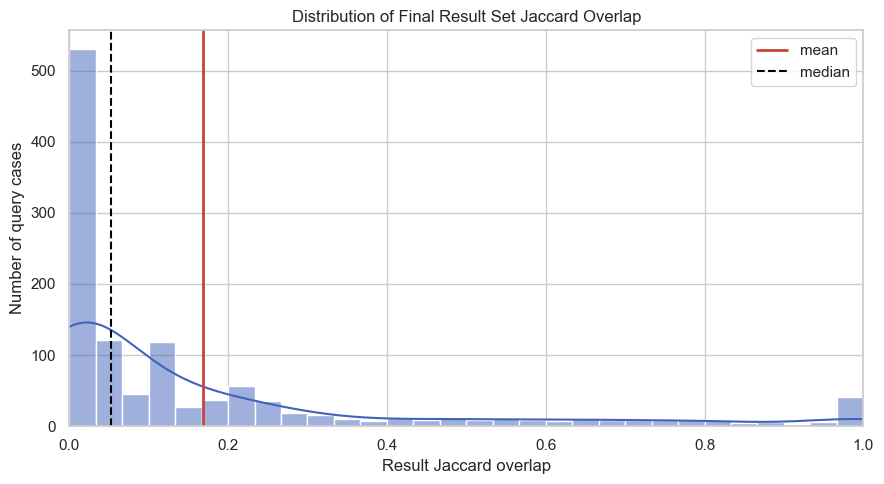

In [19]:
fig, ax = plt.subplots(figsize=(9, 5))

if sns:
    sns.histplot(result_df["result_jaccard_overlap"], bins=30, kde=True, ax=ax, color="#4062bb")
else:
    ax.hist(result_df["result_jaccard_overlap"], bins=30, color="#4062bb", alpha=0.85)

ax.axvline(result_df["result_jaccard_overlap"].mean(), color="#c44536", linewidth=2, label="mean")
ax.axvline(result_df["result_jaccard_overlap"].median(), color="black", linestyle="--", linewidth=1.5, label="median")
ax.set_title("Distribution of Final Result Set Jaccard Overlap")
ax.set_xlabel("Result Jaccard overlap")
ax.set_ylabel("Number of query cases")
ax.set_xlim(0, 1)
ax.legend()
plt.tight_layout()
plt.show()

## Plot 2: Result Jaccard Overlap by BFS Depth

BFS depth controls how far the benchmark expands from selected seed nodes.

Expected intuition:

- `depth = 0`: final results are just seed nodes, so Jaccard mostly reflects seed-set overlap.
- Larger depth: neighborhoods expand, so result sets can become much larger and may overlap more even if seed sets differ.

This plot helps answer whether native RAG changes only the seed set, or whether those differences remain visible after graph expansion.

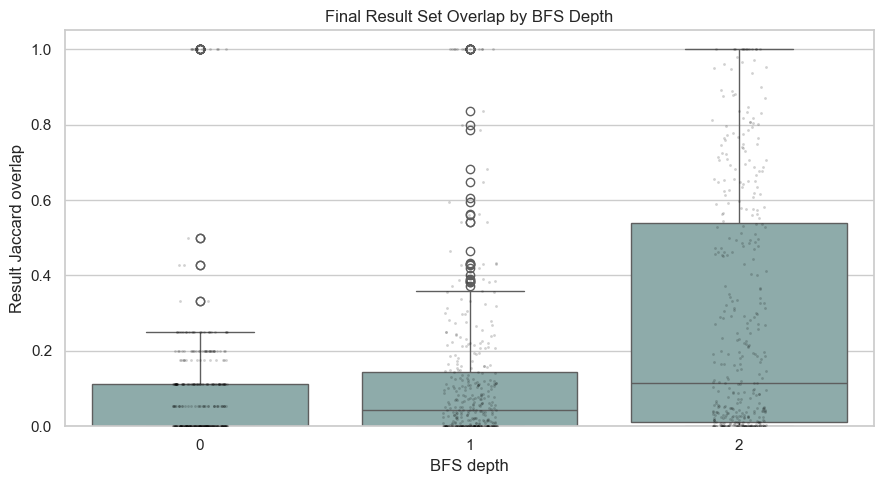

In [20]:
fig, ax = plt.subplots(figsize=(9, 5))

if sns:
    sns.boxplot(data=result_df, x="depth", y="result_jaccard_overlap", ax=ax, color="#89b0ae")
    sns.stripplot(data=result_df, x="depth", y="result_jaccard_overlap", ax=ax, color="black", alpha=0.18, size=2)
else:
    depths = sorted(result_df["depth"].dropna().unique())
    data = [result_df[result_df["depth"] == d]["result_jaccard_overlap"] for d in depths]
    ax.boxplot(data, labels=depths)

ax.set_title("Final Result Set Overlap by BFS Depth")
ax.set_xlabel("BFS depth")
ax.set_ylabel("Result Jaccard overlap")
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

## Plot 3: Mean Result Jaccard by `top_k` and `depth`

This heatmap shows where native RAG differs most from the baseline.

How to read it:

- Lower values mean native and baseline returned more different final result sets.
- Higher values mean the final result sets were more similar.
- This helps identify whether differences are strongest at small/large `top_k`, shallow/deep BFS, or both.

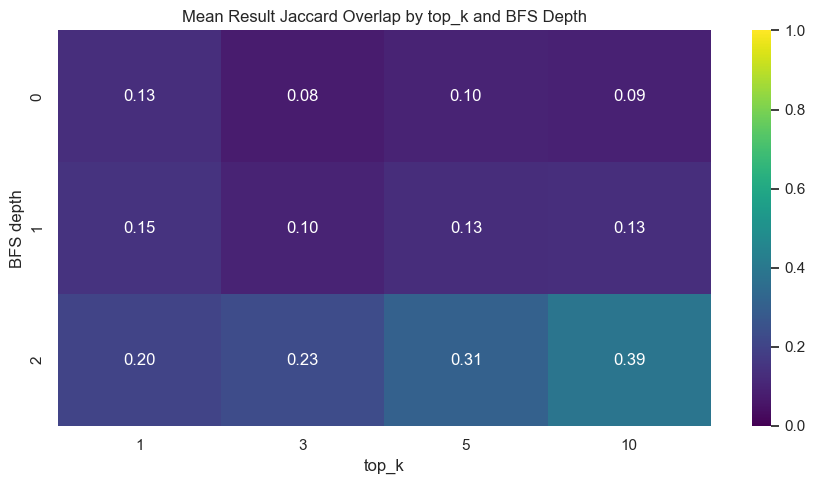

top_k,1,3,5,10
depth,,,,
0,0.130000,0.076000,0.095516,0.093722
1,0.145676,0.095152,0.126232,0.132554
2,0.202485,0.228672,0.307323,0.387897


In [21]:
heatmap_df = result_df.pivot_table(
    index="depth",
    columns="top_k",
    values="result_jaccard_overlap",
    aggfunc="mean",
)

fig, ax = plt.subplots(figsize=(9, 5))

if sns:
    sns.heatmap(heatmap_df, annot=True, fmt=".2f", cmap="viridis", vmin=0, vmax=1, ax=ax)
else:
    im = ax.imshow(heatmap_df.values, aspect="auto", vmin=0, vmax=1, cmap="viridis")
    ax.set_xticks(range(len(heatmap_df.columns)))
    ax.set_xticklabels(heatmap_df.columns)
    ax.set_yticks(range(len(heatmap_df.index)))
    ax.set_yticklabels(heatmap_df.index)
    fig.colorbar(im, ax=ax, label="Mean Jaccard")

ax.set_title("Mean Result Jaccard Overlap by top_k and BFS Depth")
ax.set_xlabel("top_k")
ax.set_ylabel("BFS depth")
plt.tight_layout()
plt.show()

heatmap_df

## Optional Plot 4: Row Count Difference by Depth

This plot looks at whether native RAG tends to return more or fewer final rows than the baseline.

Remember:

`row_count_difference = native_row_count - baseline_row_count`

How to read it:

- Values below `0`: native returned fewer final rows.
- Values above `0`: native returned more final rows.
- Values near `0`: both methods returned similar result counts.

This is separate from Jaccard overlap. Two methods can return the same number of rows but different nodes, or different numbers of rows with substantial overlap.

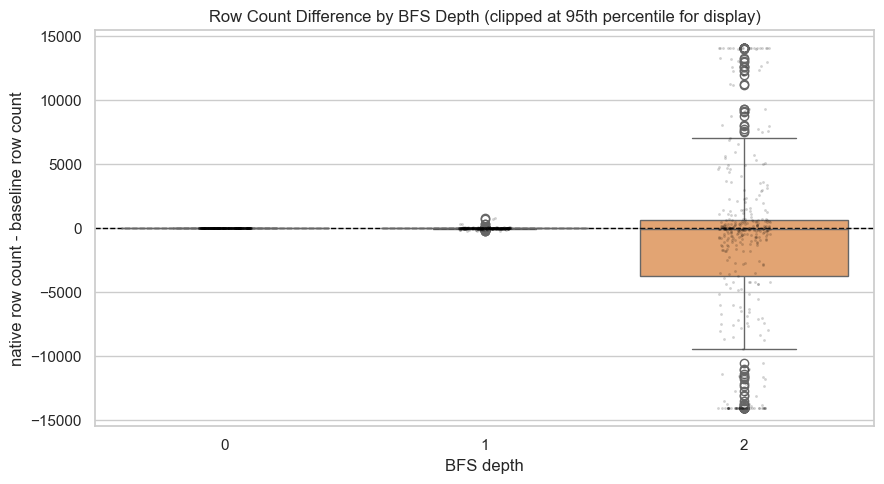

In [22]:
fig, ax = plt.subplots(figsize=(9, 5))

# Clip extreme differences for visualization only, because deep BFS can create very large row-count swings.
clip_limit = result_df["row_count_difference"].abs().quantile(0.95)
plot_df = result_df.copy()
plot_df["row_count_difference_clipped"] = plot_df["row_count_difference"].clip(-clip_limit, clip_limit)

if sns:
    sns.boxplot(data=plot_df, x="depth", y="row_count_difference_clipped", ax=ax, color="#f4a261")
    sns.stripplot(data=plot_df, x="depth", y="row_count_difference_clipped", ax=ax, color="black", alpha=0.18, size=2)
else:
    depths = sorted(plot_df["depth"].dropna().unique())
    data = [plot_df[plot_df["depth"] == d]["row_count_difference_clipped"] for d in depths]
    ax.boxplot(data, labels=depths)

ax.axhline(0, color="black", linestyle="--", linewidth=1)
ax.set_title("Row Count Difference by BFS Depth (clipped at 95th percentile for display)")
ax.set_xlabel("BFS depth")
ax.set_ylabel("native row count - baseline row count")
plt.tight_layout()
plt.show()

## Optional Plot 5: Shared vs Native-Only vs Baseline-Only Counts

This stacked chart shows the composition of final result sets by depth.

Because deep BFS can produce very large result sets, this plot uses means by depth rather than raw query-level counts.

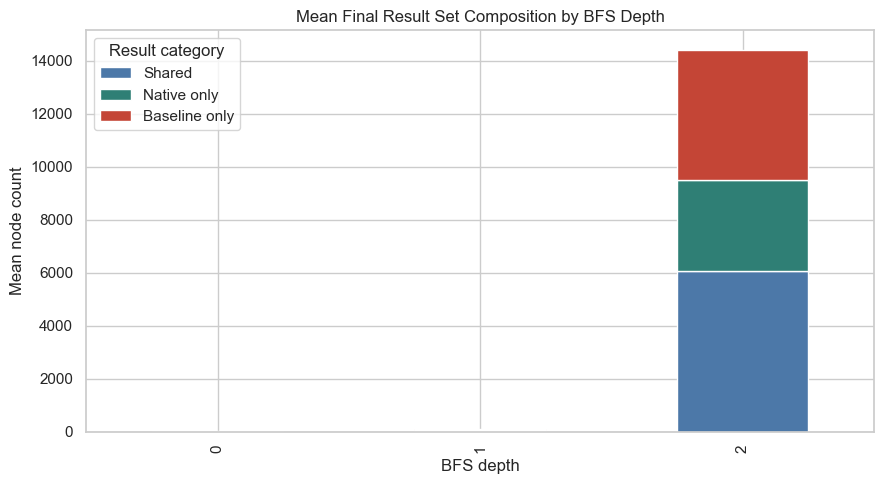

,shared,native_only,baseline_only
depth,,,
0,0.735,4.0150,4.0150
1,12.940,47.4000,46.2125
2,6073.215,3415.4125,4931.1975


In [23]:
composition = result_df.groupby("depth", as_index=True).agg(
    shared=("shared_result_count", "mean"),
    native_only=("native_only_count", "mean"),
    baseline_only=("baseline_only_count", "mean"),
)

fig, ax = plt.subplots(figsize=(9, 5))
composition.plot(kind="bar", stacked=True, ax=ax, color=["#4c78a8", "#2f7f75", "#c44536"])
ax.set_title("Mean Final Result Set Composition by BFS Depth")
ax.set_xlabel("BFS depth")
ax.set_ylabel("Mean node count")
ax.legend(title="Result category", labels=["Shared", "Native only", "Baseline only"])
plt.tight_layout()
plt.show()

composition

## Label Diversity: Native vs Baseline Unique Label Count

The `unique_label_count` fields use the OGBN-Arxiv paper category labels as a coarse topical-diversity proxy.

Columns:

- `native_unique_label_count`: number of distinct labels in the final native RAG result set
- `baseline_unique_label_count`: number of distinct labels in the final two-call baseline result set

How to read this:

- Higher unique label count means the result set spans more paper categories.
- Similar counts mean both methods cover similar category breadth.
- Native higher than baseline suggests native RAG may be retrieving a more category-diverse result set.
- Baseline higher than native suggests the baseline may be retrieving a more category-diverse result set.

Important caveat:

Unique label count does not measure semantic correctness. It only measures broad category coverage in the returned result set.

In [24]:
LABEL_COLS = ["native_unique_label_count", "baseline_unique_label_count"]

for col in LABEL_COLS:
    result_df[col] = pd.to_numeric(result_df[col], errors="coerce")

label_df = result_df[
    result_df["native_unique_label_count"].notna()
    & result_df["baseline_unique_label_count"].notna()
].copy()

label_df["unique_label_count_difference"] = (
    label_df["native_unique_label_count"] - label_df["baseline_unique_label_count"]
)
label_df["label_diversity_winner"] = label_df["unique_label_count_difference"].map(
    lambda x: "native_higher" if x > 0 else ("tie" if x == 0 else "baseline_higher")
)

label_summary = {
    "row_count": len(label_df),
    "mean_native_unique_label_count": label_df["native_unique_label_count"].mean(),
    "mean_baseline_unique_label_count": label_df["baseline_unique_label_count"].mean(),
    "mean_unique_label_count_difference_native_minus_baseline": label_df["unique_label_count_difference"].mean(),
    "median_unique_label_count_difference_native_minus_baseline": label_df["unique_label_count_difference"].median(),
    "native_higher_fraction": (label_df["unique_label_count_difference"] > 0).mean(),
    "tie_fraction": (label_df["unique_label_count_difference"] == 0).mean(),
    "baseline_higher_fraction": (label_df["unique_label_count_difference"] < 0).mean(),
}

pd.Series(label_summary).to_frame("value")

,value
row_count,1200.000000
mean_native_unique_label_count,11.700000
mean_baseline_unique_label_count,11.845833
mean_unique_label_count_difference_native_minus_baseline,-0.145833
median_unique_label_count_difference_native_minus_baseline,0.000000
native_higher_fraction,0.380833
tie_fraction,0.311667
baseline_higher_fraction,0.307500


### Plot 6: Paired Unique Label Count Scatter

This plot compares native and baseline unique label counts for each query case.

How to read it:

- Points above the diagonal mean native RAG returned more unique labels.
- Points on the diagonal mean both methods returned the same number of unique labels.
- Points below the diagonal mean the baseline returned more unique labels.

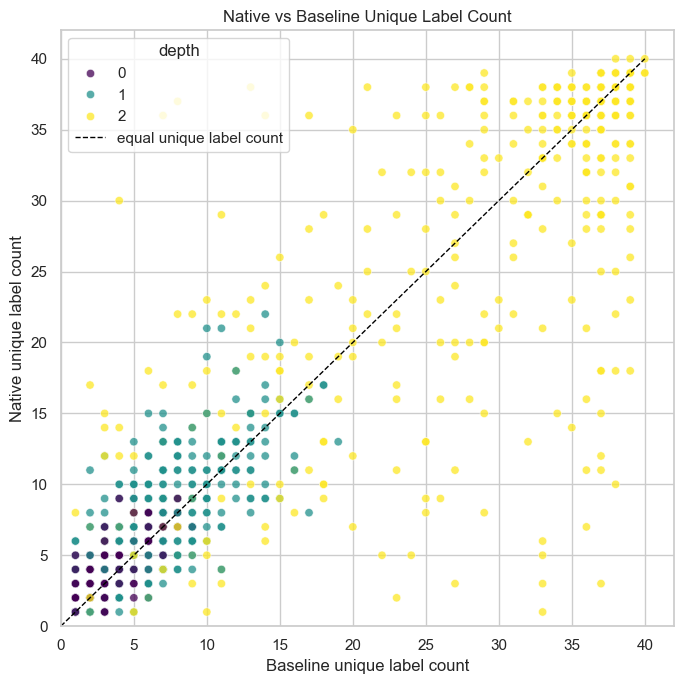

In [25]:
fig, ax = plt.subplots(figsize=(7, 7))

if sns:
    sns.scatterplot(
        data=label_df,
        x="baseline_unique_label_count",
        y="native_unique_label_count",
        hue="depth",
        palette="viridis",
        alpha=0.75,
        ax=ax,
    )
else:
    scatter = ax.scatter(
        label_df["baseline_unique_label_count"],
        label_df["native_unique_label_count"],
        c=label_df["depth"],
        alpha=0.75,
    )
    fig.colorbar(scatter, ax=ax, label="depth")

max_val = max(label_df["baseline_unique_label_count"].max(), label_df["native_unique_label_count"].max())
ax.plot([0, max_val], [0, max_val], linestyle="--", color="black", linewidth=1, label="equal unique label count")

ax.set_title("Native vs Baseline Unique Label Count")
ax.set_xlabel("Baseline unique label count")
ax.set_ylabel("Native unique label count")
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)
ax.legend(title="depth", loc="best")
plt.tight_layout()
plt.show()

### Plot 7: Mean Unique Label Count by BFS Depth

This plot shows whether one method tends to return broader label/category coverage as BFS depth increases.

How to read it:

- If native is higher, native result sets include more distinct paper labels on average.
- If baseline is higher, baseline result sets include more distinct paper labels on average.
- If both rise with depth, that is expected: deeper BFS usually returns more nodes and therefore more categories.

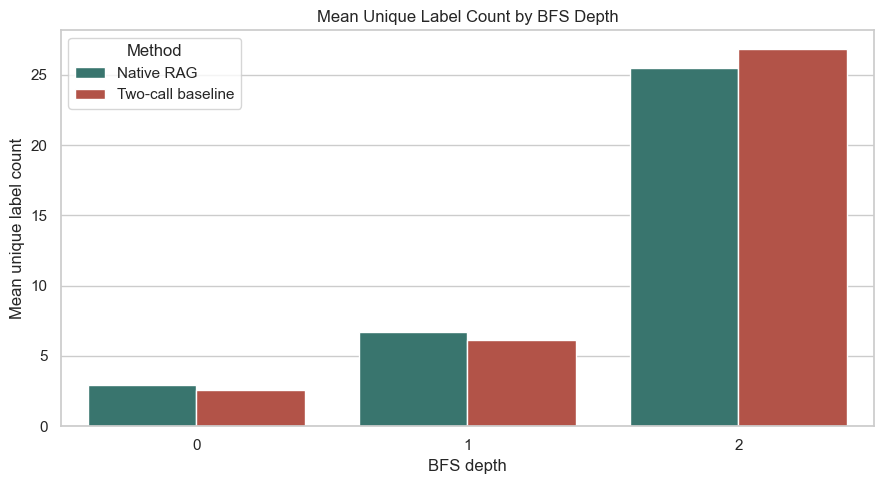

,depth,cases,native_mean_unique_label_count,baseline_mean_unique_label_count,mean_unique_label_count_difference
0,0,400,2.9075,2.5975,0.3100
1,1,400,6.6925,6.1150,0.5775
2,2,400,25.5000,26.8250,-1.3250


In [26]:
label_by_depth = label_df.groupby("depth", as_index=False).agg(
    cases=("query_id", "count"),
    native_mean_unique_label_count=("native_unique_label_count", "mean"),
    baseline_mean_unique_label_count=("baseline_unique_label_count", "mean"),
    mean_unique_label_count_difference=("unique_label_count_difference", "mean"),
)

plot_label_depth = label_by_depth.melt(
    id_vars=["depth"],
    value_vars=["native_mean_unique_label_count", "baseline_mean_unique_label_count"],
    var_name="method",
    value_name="mean_unique_label_count",
)
plot_label_depth["method"] = plot_label_depth["method"].map({
    "native_mean_unique_label_count": "Native RAG",
    "baseline_mean_unique_label_count": "Two-call baseline",
})

fig, ax = plt.subplots(figsize=(9, 5))

if sns:
    sns.barplot(data=plot_label_depth, x="depth", y="mean_unique_label_count", hue="method", ax=ax, palette=["#2f7f75", "#c44536"])
else:
    pivot = plot_label_depth.pivot(index="depth", columns="method", values="mean_unique_label_count")
    pivot.plot(kind="bar", ax=ax, color=["#2f7f75", "#c44536"])

ax.set_title("Mean Unique Label Count by BFS Depth")
ax.set_xlabel("BFS depth")
ax.set_ylabel("Mean unique label count")
ax.legend(title="Method")
plt.tight_layout()
plt.show()

label_by_depth

### Plot 8: Unique Label Count Difference Distribution

This histogram shows:

`native_unique_label_count - baseline_unique_label_count`

How to read it:

- Values above `0`: native returned more unique labels.
- Values equal to `0`: both methods returned the same number of unique labels.
- Values below `0`: baseline returned more unique labels.

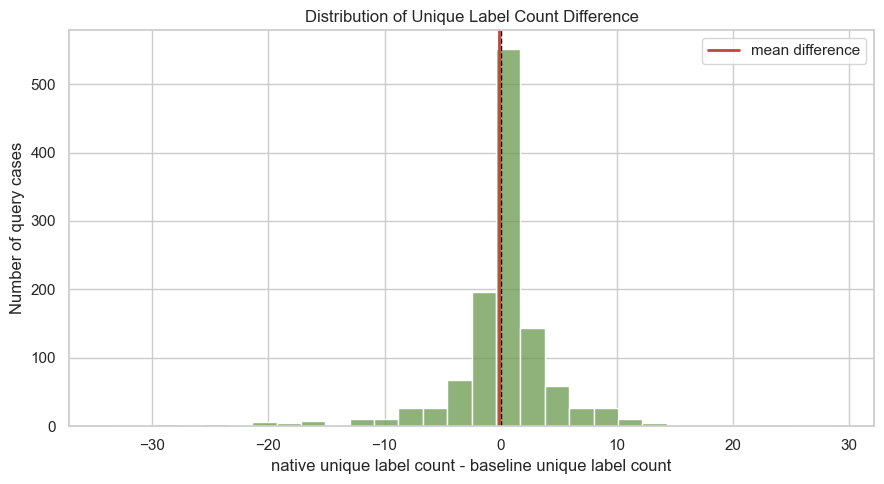

In [27]:
fig, ax = plt.subplots(figsize=(9, 5))

if sns:
    sns.histplot(label_df["unique_label_count_difference"], bins=30, kde=False, ax=ax, color="#6a994e")
else:
    ax.hist(label_df["unique_label_count_difference"], bins=30, color="#6a994e", alpha=0.85)

ax.axvline(0, color="black", linestyle="--", linewidth=1)
ax.axvline(label_df["unique_label_count_difference"].mean(), color="#c44536", linewidth=2, label="mean difference")
ax.set_title("Distribution of Unique Label Count Difference")
ax.set_xlabel("native unique label count - baseline unique label count")
ax.set_ylabel("Number of query cases")
ax.legend()
plt.tight_layout()
plt.show()

## Suggested Report Interpretation

You can adapt this wording after checking the final numbers:

> We used result-set Jaccard overlap to measure how much native RAG changed the final retrieved node set relative to the two-call baseline. A Jaccard score of 1.0 means both methods returned the same nodes, while lower values indicate increasingly different outputs. This metric does not measure correctness directly; instead, it measures whether the native seed-reranking strategy produces meaningfully different retrieval results.

Possible interpretations:

- **High Jaccard overlap:** native RAG changes seed selection, but BFS expansion eventually reaches many of the same nodes.
- **Low Jaccard overlap:** native RAG changes not only seed selection but also the final graph regions retrieved.
- **Jaccard increases with depth:** different seeds eventually expand into overlapping graph neighborhoods.
- **Jaccard decreases with larger top_k:** selecting more seeds gives the reranker more room to choose different graph regions.
- **Native row count lower than baseline:** native may be selecting less connected or less redundant seed regions.
- **Native row count higher than baseline:** native may be selecting seeds that expand into larger graph neighborhoods.

Important caveat:

> Result-set overlap is a behavioral difference metric, not an accuracy metric. Without ground-truth relevant documents or human labels, it should be interpreted as evidence that native RAG changes retrieval coverage, not as proof that one method is more semantically correct.